<a href="https://colab.research.google.com/github/richieaneks/Richard-Chidubem-Aniekwe/blob/dev/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/richieaneks/Richard-Chidubem-Aniekwe.git
%cd Richard-Chidubem-Aniekwe
!git checkout dev

Cloning into 'Richard-Chidubem-Aniekwe'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 90 (delta 45), reused 49 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 1.64 MiB | 10.22 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/Richard-Chidubem-Aniekwe
Branch 'dev' set up to track remote branch 'dev' from 'origin'.
Switched to a new branch 'dev'


In [23]:
!pip install simple_pid

In [24]:
import numpy as np
from simple_pid import PID
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
from dc_motor_env import motor_dynamics, DCMotorEnv, NOMINAL_PARAMS

## Open loop

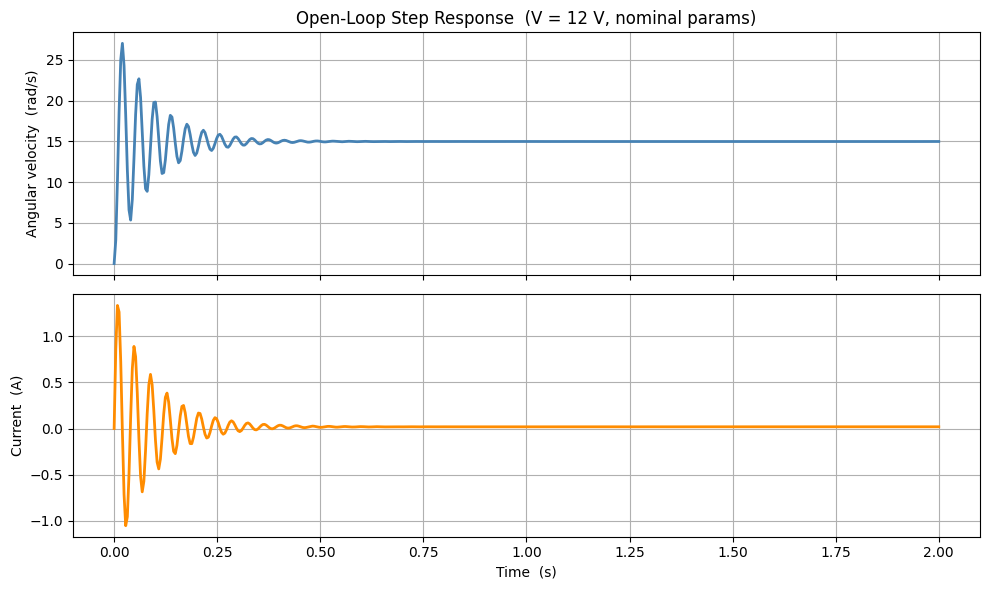

In [ ]:
sol = solve_ivp(motor_dynamics, [0, 2], [0, 0],
                    args=(12.0, 0.0, NOMINAL_PARAMS),
                    t_eval=np.linspace(0, 2, 500))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(sol.t, sol.y[0], color='steelblue', linewidth=2)
axes[0].set_ylabel('Angular velocity  (rad/s)')
axes[0].set_title('Open-Loop Step Response  (V = 12 V, nominal params)')
axes[0].grid(True)

axes[1].plot(sol.t, sol.y[1], color='darkorange', linewidth=2)
axes[1].set_ylabel('Current  (A)')
axes[1].set_xlabel('Time  (s)')
axes[1].grid(True)

plt.tight_layout()

In [47]:
state = [0.0, 0.0]
dt = 0.01
target = 15
load_torque = 0.0
V = 0.0
log = []
max_steps = 1000
Kp=10
Kd=0.01 # Derivative gain
Ki = 0.0001
pid_drive = PID(Kp, Ki, Kd)
prev_error = 0.0 # Initialize previous error
t0, tf = 0, dt
for _ in range(max_steps):
    omega, current = state

    error = target - omega
    d_error = (error - prev_error) / dt # Calculate derivative of error

    ctrl = pid_drive(-error) #Kp * error + Kd * d_error # PD
    V = float(np.clip(ctrl, -12.0, 12.0))

    sol = solve_ivp(
            motor_dynamics,[t0,tf], state,
            args=(V, load_torque, NOMINAL_PARAMS),
            dense_output=False)
    state=sol.y[:,-1]
    #t0 = tf
    #tf += dt
    log.append([omega, current, error])
    prev_error = error # Update previous error for the next iteration
log = np.array(log)

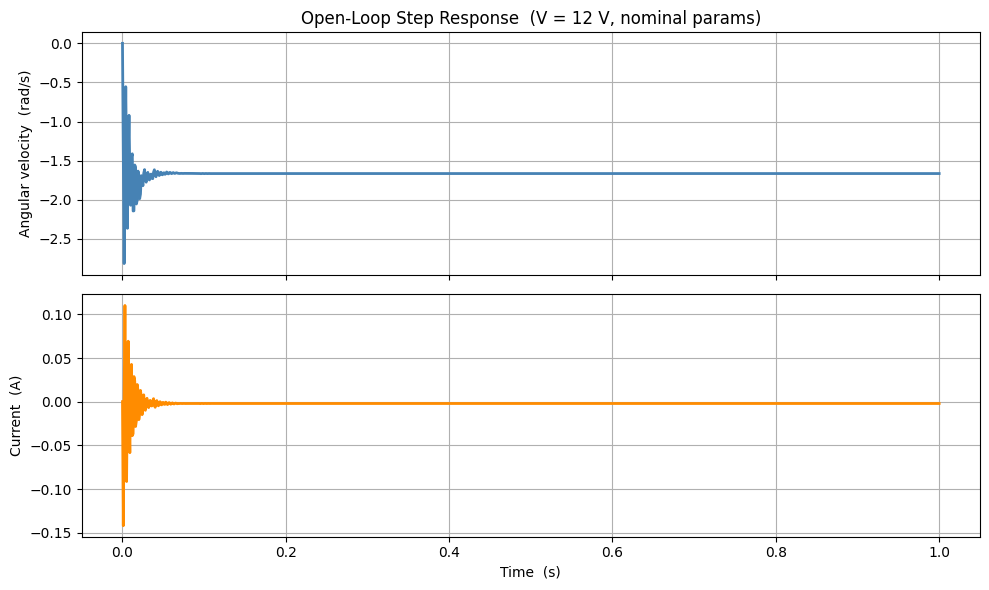

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(np.linspace(0, 1, max_steps), log[:,0], color='steelblue', linewidth=2)
axes[0].set_ylabel('Angular velocity  (rad/s)')
axes[0].set_title('Open-Loop Step Response  (V = 12 V, nominal params)')
axes[0].grid(True)

axes[1].plot(np.linspace(0, 1, max_steps), log[:,1], color='darkorange', linewidth=2)
axes[1].set_ylabel('Current  (A)')
axes[1].set_xlabel('Time  (s)')
axes[1].grid(True)

plt.tight_layout()

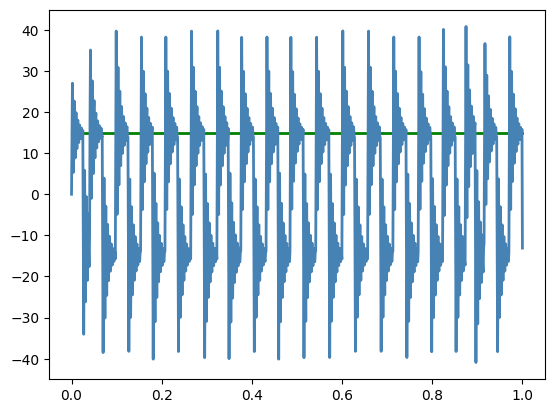

In [48]:
plt.plot(np.linspace(0, 1, max_steps), [target]*max_steps, color='green', linewidth=2)
plt.plot(np.linspace(0, 1, max_steps), log[:,0], color='steelblue', linewidth=2)